<div style="background-color:#00843D;padding:22px 28px;border-radius:12px;margin-bottom:4px">
  <h2 style="color:white;margin:0;font-size:22px">Analisis Numerico</h2>
  <p style="color:#b8f0c8;margin:6px 0 2px;font-size:14px">Universidad Nacional de Colombia - Sede Manizales</p>
  <p style="color:#b8f0c8;margin:0;font-size:14px">Prof. Carlos Manuel Orrego Franco</p>
</div>

---

# Notebook 02: El Perceptron
## De la neurona biologica a la primera red que aprende

---

### Objetivos de aprendizaje

Al finalizar este notebook seras capaz de:

1. **Explicar** la abstraccion que hace McCulloch-Pitts de la neurona biologica
2. **Implementar** la neurona de McCulloch-Pitts desde cero en NumPy
3. **Implementar** el algoritmo de aprendizaje del Perceptron de Rosenblatt
4. **Visualizar** la frontera de decision que aprende el Perceptron
5. **Identificar** las limitaciones del Perceptron y por que llevan al invierno de la IA

### Prerequisitos

- Notebook 01: FitzHugh-Nagumo (completado)
- Producto punto y algebra lineal basica
- Python y NumPy

---

> **Como leer este notebook:**
> - Las celdas marcadas con **[OK]** estan listas: presiona `Shift+Enter`
> - Las celdas marcadas con **[Ejercicio]** son para completar antes de continuar


## 1. De donde venimos: la abstraccion de la neurona

En el Notebook 01 vimos que una neurona biologica es un **sistema dinamico no lineal**
con potenciales de accion, ciclos limite y escalas de tiempo separadas.

Simular ese sistema para redes grandes es computacionalmente inviable.

La pregunta que se hicieron McCulloch y Pitts en 1943 fue radical:

> *"Si queremos que una maquina calcule como el cerebro,*
> *no necesitamos simular cada canal ionico.*
> *Solo necesitamos capturar la **funcion** que realiza la neurona."*

---

### Que hace realmente una neurona?

Reduciendo al maximo esencial:

```
   x1 ---(w1)--->
   x2 ---(w2)---> [SUMA PONDERADA] ---> [UMBRAL] ---> salida (0 o 1)
   x3 ---(w3)--->
```

1. **Recibe** senales de otras neuronas: $x_1, x_2, \ldots, x_n$
2. **Pondera** cada senal: multiplicar por un peso $w_i$
3. **Suma** todo: $z = w_1 x_1 + w_2 x_2 + \cdots + w_n x_n$
4. **Dispara** (salida = 1) si $z$ supera un umbral $\theta$; si no, silencio (salida = 0)

En notacion compacta usando el **producto punto**:

$$z = \mathbf{w}^T \mathbf{x} = \sum_{i=1}^{n} w_i x_i$$

$$\text{salida} = \begin{cases} 1 & \text{si} \quad z > \theta \\ 0 & \text{si} \quad z \leq \theta \end{cases}$$

**Esto es todo.** Cuatro decadas de biologia comprimidas en dos ecuaciones.


## 2. Linea de tiempo: donde estamos hoy

Este notebook cubre los hitos marcados con (*) en el recorrido historico.


In [12]:
# [OK] Ejecuta esta celda primero

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

plt.rcParams.update({
    "figure.dpi": 120,
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "lines.linewidth": 2.0,
    "figure.facecolor": "white",
    "axes.facecolor": "#fafafa",
})

VERDE   = "#00843D"
AZUL    = "#1a5fa8"
ROJO    = "#c0392b"
NARANJA = "#e67e22"
MORADO  = "#8e44ad"
GRIS    = "#7f8c8d"

np.random.seed(42)
print("Librerias cargadas correctamente.")


Librerias cargadas correctamente.


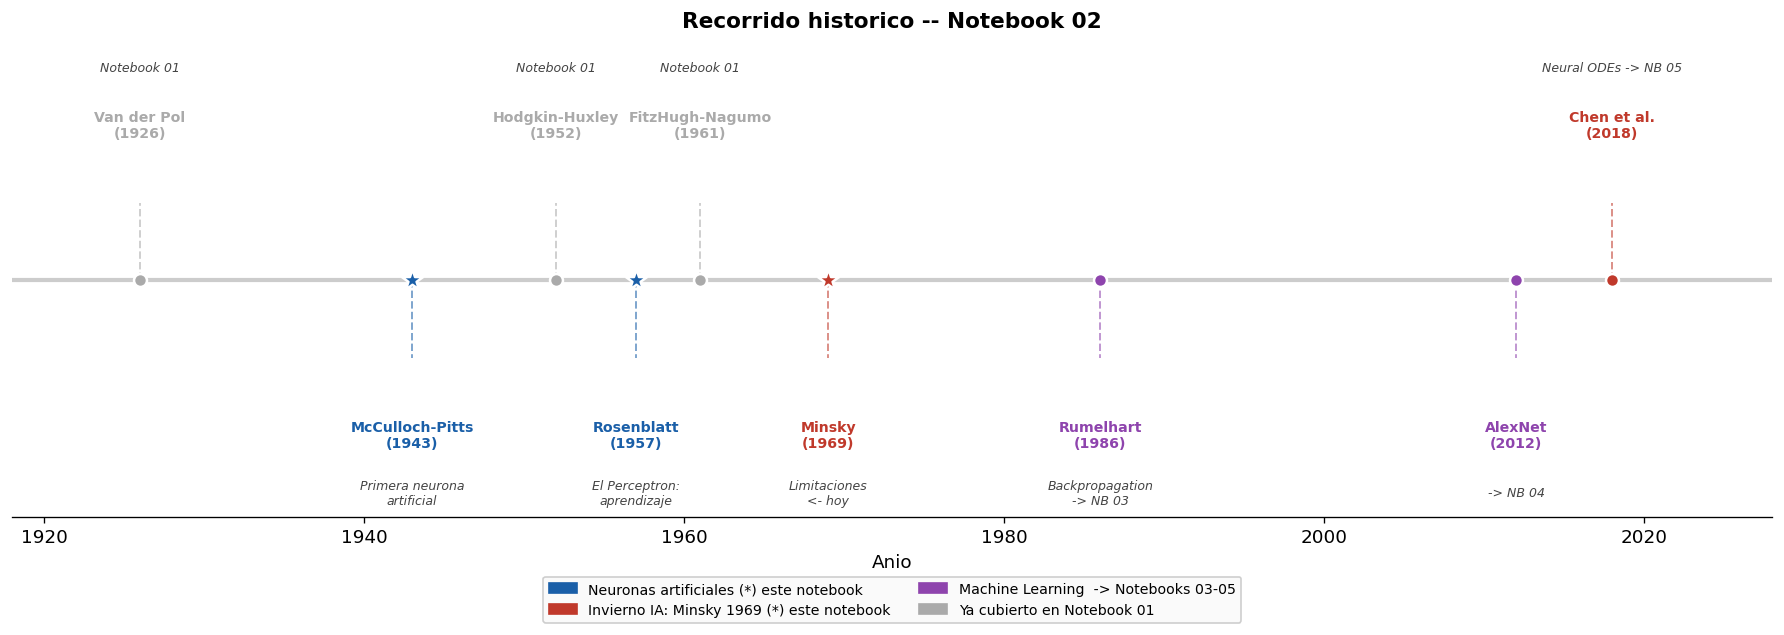

In [13]:
# [OK] Linea de tiempo historica -- hitos de este notebook

fig, ax = plt.subplots(figsize=(15, 5.5))
ax.set_facecolor("white"); ax.grid(False)
ax.set_xlim(1918, 2028); ax.set_ylim(-3.2, 3.2)
ax.axhline(0, color="#cccccc", linewidth=2.5, zorder=1)

hitos = [
    (1926, +2.1, "Van der Pol\n(1926)",       "Notebook 01",                  "#aaa",  False),
    (1943, -2.1, "McCulloch-Pitts\n(1943)",   "Primera neurona\nartificial",  AZUL,    True),
    (1952, +2.1, "Hodgkin-Huxley\n(1952)",    "Notebook 01",                  "#aaa",  False),
    (1957, -2.1, "Rosenblatt\n(1957)",        "El Perceptron:\naprendizaje",  AZUL,    True),
    (1961, +2.1, "FitzHugh-Nagumo\n(1961)",   "Notebook 01",                  "#aaa",  False),
    (1969, -2.1, "Minsky\n(1969)",            "Limitaciones\n<- hoy",         ROJO,    True),
    (1986, -2.1, "Rumelhart\n(1986)",         "Backpropagation\n-> NB 03",    MORADO,  False),
    (2012, -2.1, "AlexNet\n(2012)",           "-> NB 04",                     MORADO,  False),
    (2018, +2.1, "Chen et al.\n(2018)",       "Neural ODEs -> NB 05",         ROJO,    False),
]

for anio, y, titulo, desc, color, hoy in hitos:
    mk = "*" if hoy else "o"; sz = 180 if hoy else 60
    ax.scatter(anio, 0, s=sz, color=color, zorder=6, marker=mk,
               edgecolors="white", linewidths=1.5)
    ax.plot([anio, anio], [0, y*0.5], color=color,
            linewidth=1.2, linestyle="--", alpha=0.55, zorder=2)
    ax.text(anio, y, titulo, ha="center", va="center",
            fontsize=8.5, fontweight="bold", color=color)
    ay = y + (0.78 if y > 0 else -0.78)
    ax.text(anio, ay, desc, ha="center", va="center",
            fontsize=7.5, color="#444", style="italic")

leyenda = [
    mpatches.Patch(color=AZUL,  label="Neuronas artificiales (*) este notebook"),
    mpatches.Patch(color=ROJO,  label="Invierno IA: Minsky 1969 (*) este notebook"),
    mpatches.Patch(color=MORADO,label="Machine Learning  -> Notebooks 03-05"),
    mpatches.Patch(color="#aaa", label="Ya cubierto en Notebook 01"),
]
ax.legend(handles=leyenda, loc="lower center", ncol=2, fontsize=8.5,
          framealpha=0.95, bbox_to_anchor=(0.5, -0.24))
ax.set_xlabel("Anio", fontsize=11)
ax.set_title("Recorrido historico -- Notebook 02", fontsize=13, fontweight="bold", pad=10)
ax.set_yticks([])
for sp in ax.spines.values(): sp.set_visible(False)
ax.spines["bottom"].set_visible(True)
plt.tight_layout(); plt.show()


## 3. Herramienta clave: el producto punto en NumPy

Antes de implementar la neurona, necesitamos entender una operacion fundamental.

La suma ponderada $z = \sum_i w_i x_i$ es exactamente un **producto punto**.
NumPy lo calcula en una sola linea con el operador `@`:

```python
z = w @ x      # equivale a sum(w[i] * x[i] for i in range(n))
```

| Operacion matematica | Codigo Python |
|---------------------|---------------|
| $z = \mathbf{w}^T \mathbf{x}$ | `z = w @ x` |
| $z = \sum_i w_i x_i$ | `z = np.dot(w, x)` |
| $\mathbf{y} = W \mathbf{x}$ (matriz) | `y = W @ x` |

> **Por que importa esto?** Todo el aprendizaje profundo -- redes convolucionales,
> transformers, GPT -- se reduce en su nucleo a operaciones de este tipo,
> ejecutadas de forma masivamente paralela en GPU.
> La GPU no es mas que un procesador especializado en hacer millones de `w @ x`
> al mismo tiempo.


Entradas x: [ 1.   0.5 -1. ]
Pesos    w: [0.8 0.4 0.6]

Suma manual:  0.4000
np.dot(w,x):  0.4000
w @ x:         0.4000



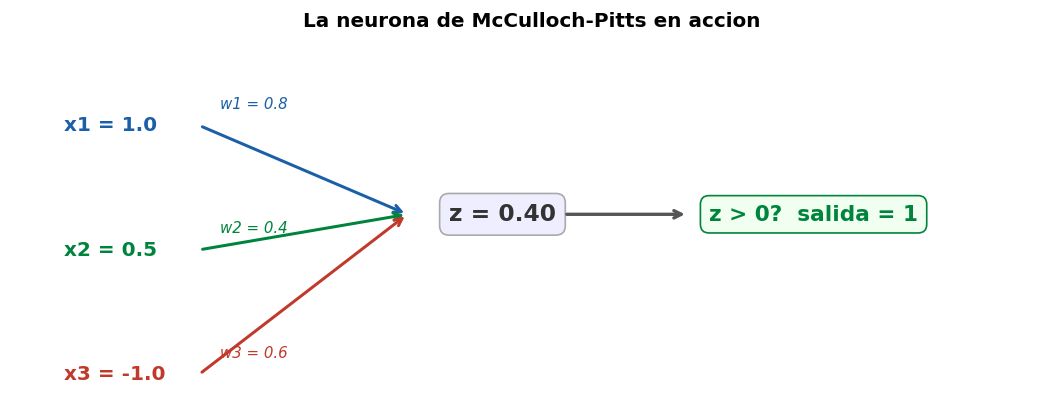

In [14]:
# [OK] El producto punto: base de todo el aprendizaje profundo

# Ejemplo: neurona con 3 entradas
x = np.array([1.0, 0.5, -1.0])   # senales de entrada
w = np.array([0.8, 0.4,  0.6])   # pesos de cada conexion

# Tres formas equivalentes de calcular la suma ponderada
z_manual = sum(w[i]*x[i] for i in range(len(x)))
z_dot    = np.dot(w, x)
z_arroba = w @ x

print("Entradas x:", x)
print("Pesos    w:", w)
print()
print(f"Suma manual:  {z_manual:.4f}")
print(f"np.dot(w,x):  {z_dot:.4f}")
print(f"w @ x:         {z_arroba:.4f}")
print()

# Visualizar la operacion
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.set_facecolor("white"); ax.axis("off")

colores_x = [AZUL, VERDE, ROJO]
labels_x  = ["x1 = 1.0", "x2 = 0.5", "x3 = -1.0"]
labels_w  = ["w1 = 0.8", "w2 = 0.4", "w3 = 0.6"]

for i, (lx, lw, color) in enumerate(zip(labels_x, labels_w, colores_x)):
    y_pos = 0.75 - i * 0.35
    ax.text(0.05, y_pos, lx, transform=ax.transAxes, fontsize=12,
            color=color, fontweight="bold", va="center")
    ax.annotate("", xy=(0.38, 0.5), xytext=(0.18, y_pos),
                xycoords="axes fraction",
                arrowprops=dict(arrowstyle="->", color=color, lw=1.8))
    ax.text(0.20, y_pos + 0.06, lw, transform=ax.transAxes,
            fontsize=9, color=color, va="center", style="italic")

ax.text(0.42, 0.50, f"z = {z_arroba:.2f}", transform=ax.transAxes,
        fontsize=14, fontweight="bold", color="#333", va="center",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#eef", edgecolor="#aaa"))

ax.annotate("", xy=(0.65, 0.50), xytext=(0.53, 0.50),
            xycoords="axes fraction",
            arrowprops=dict(arrowstyle="->", color="#555", lw=2))

salida = 1 if z_arroba > 0 else 0
color_sal = VERDE if salida == 1 else GRIS
ax.text(0.67, 0.50, f"z > 0?  salida = {salida}", transform=ax.transAxes,
        fontsize=13, fontweight="bold", color=color_sal, va="center",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#f0fff0" if salida else "#f5f5f5",
                  edgecolor=color_sal))

ax.set_title("La neurona de McCulloch-Pitts en accion", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()


In [15]:
# [Ejercicio 1] Implementar la neurona de McCulloch-Pitts

def mcculloch_pitts(x, w, theta):
    """
    Neurona de McCulloch-Pitts.

    Parametros
    ----------
    x     : array de entradas
    w     : array de pesos (mismo tamano que x)
    theta : umbral de activacion

    Retorna
    -------
    1 si w @ x > theta, 0 en caso contrario
    """
    # ================================================
    # [Ejercicio] Completa la funcion.
    # Paso 1: calcula la suma ponderada z = w @ x
    # Paso 2: retorna 1 si z > theta, 0 si no
    # ================================================
    z = np.dot(w,x)   # <- calcula la suma ponderada
    if z > theta:   # <- aplica el umbral
      salida = 1
    else:
      salida = 0
    return salida


# Verificacion: compuertas logicas clasicas
# La neurona de McCulloch-Pitts puede implementar AND, OR, NOT

print("Compuerta AND  (w=[1,1], theta=1.5)")
print("  AND(0,0) =", mcculloch_pitts([0,0], [1,1], 1.5), "  esperado: 0")
print("  AND(1,0) =", mcculloch_pitts([1,0], [1,1], 1.5), "  esperado: 0")
print("  AND(0,1) =", mcculloch_pitts([0,1], [1,1], 1.5), "  esperado: 0")
print("  AND(1,1) =", mcculloch_pitts([1,1], [1,1], 1.5), "  esperado: 1")
print()
print("Compuerta OR   (w=[1,1], theta=0.5)")
print("  OR(0,0)  =", mcculloch_pitts([0,0], [1,1], 0.5), "  esperado: 0")
print("  OR(1,0)  =", mcculloch_pitts([1,0], [1,1], 0.5), "  esperado: 1")
print("  OR(0,1)  =", mcculloch_pitts([0,1], [1,1], 0.5), "  esperado: 1")
print("  OR(1,1)  =", mcculloch_pitts([1,1], [1,1], 0.5), "  esperado: 1")

Compuerta AND  (w=[1,1], theta=1.5)
  AND(0,0) = 0   esperado: 0
  AND(1,0) = 0   esperado: 0
  AND(0,1) = 0   esperado: 0
  AND(1,1) = 1   esperado: 1

Compuerta OR   (w=[1,1], theta=0.5)
  OR(0,0)  = 0   esperado: 0
  OR(1,0)  = 1   esperado: 1
  OR(0,1)  = 1   esperado: 1
  OR(1,1)  = 1   esperado: 1


## 4. La primera limitacion: XOR

La neurona de McCulloch-Pitts puede implementar AND y OR, pero hay una compuerta
que **no puede** implementar con ningun par de pesos $(w_1, w_2)$ y umbral $\theta$:

| $x_1$ | $x_2$ | XOR |
|-------|-------|-----|
| 0 | 0 | **0** |
| 1 | 0 | **1** |
| 0 | 1 | **1** |
| 1 | 1 | **0** |

Por que? Porque la condicion $w_1 x_1 + w_2 x_2 > \theta$ define una **linea recta**
en el plano $(x_1, x_2)$. XOR no puede separarse con una sola linea recta.

Esto se llama **no separabilidad lineal** y es la limitacion fundamental de una
sola neurona. En 1943 no habia una solucion clara. Rosenblatt la atacaria
en 1957 con una idea diferente: en vez de disenar los pesos manualmente,
**que la maquina los aprenda de los datos**.


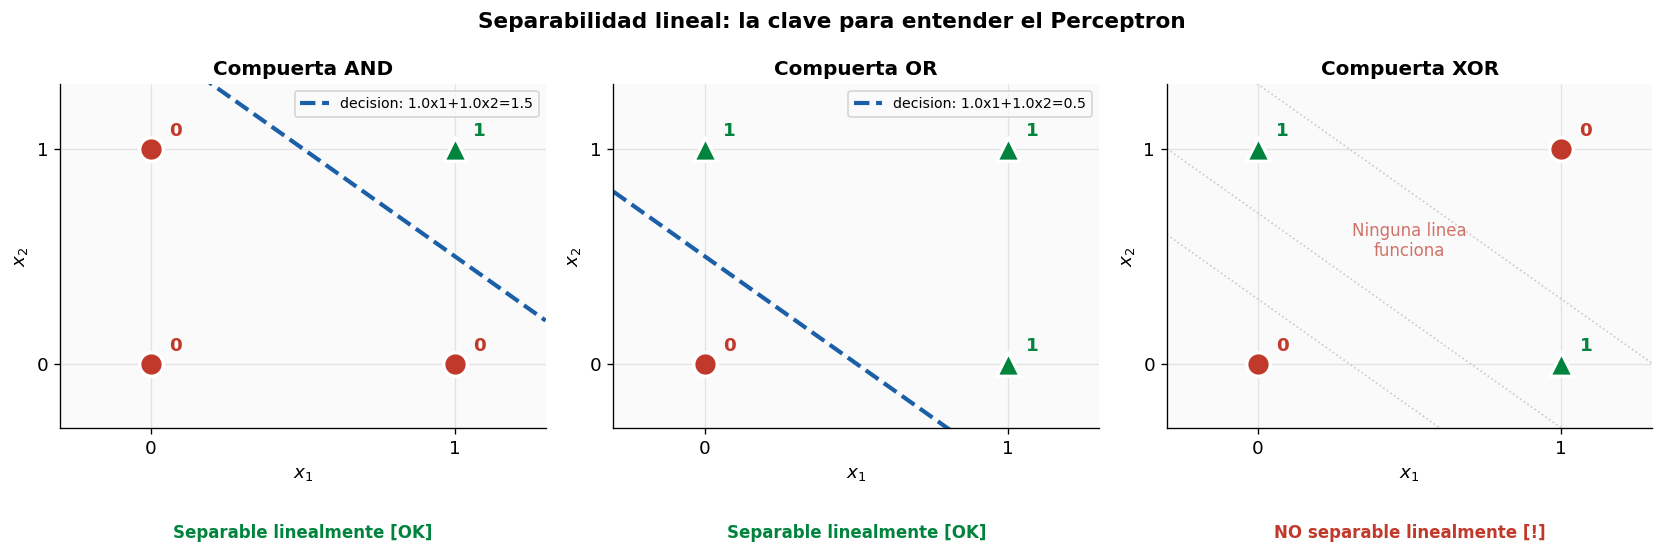

AND y OR son linealmente separables -> una sola neurona basta.
XOR no lo es -> necesitaremos varias neuronas en capas (lo veremos en NB03).


In [16]:
# [OK] Visualizar por que XOR no es linealmente separable

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
compuertas = [
    ("AND", [[0,0,0],[1,0,0],[0,1,0],[1,1,1]], [1.0, 1.0], 1.5),
    ("OR",  [[0,0,0],[1,0,1],[0,1,1],[1,1,1]], [1.0, 1.0], 0.5),
    ("XOR", [[0,0,0],[1,0,1],[0,1,1],[1,1,0]], None,       None),
]

for ax, (nombre, tabla, w, theta) in zip(axes, compuertas):
    for x1, x2, y in tabla:
        color = VERDE if y == 1 else ROJO
        marker = "^" if y == 1 else "o"
        ax.scatter(x1, x2, s=200, color=color, marker=marker,
                   zorder=5, edgecolors="white", linewidths=2)
        ax.text(x1+0.06, x2+0.06, str(y), fontsize=11, color=color, fontweight="bold")

    if w is not None:
        # Dibujar la frontera de decision: w1*x1 + w2*x2 = theta
        # => x2 = (theta - w1*x1) / w2
        x1_line = np.linspace(-0.3, 1.3, 100)
        x2_line = (theta - w[0]*x1_line) / w[1]
        ax.plot(x1_line, x2_line, color=AZUL, linewidth=2.5,
                linestyle="--", label=f"decision: {w[0]}x1+{w[1]}x2={theta}")
        ax.legend(fontsize=8.5)
        ax.text(0.5, -0.32, "Separable linealmente [OK]",
                ha="center", fontsize=10, color=VERDE, fontweight="bold",
                transform=ax.transAxes)
    else:
        ax.text(0.5, -0.32, "NO separable linealmente [!]",
                ha="center", fontsize=10, color=ROJO, fontweight="bold",
                transform=ax.transAxes)
        # Intentar algunas lineas -- ninguna funciona
        for th in [0.3, 0.7, 1.3]:
            x1_line = np.linspace(-0.3, 1.3, 100)
            x2_line = th - x1_line
            ax.plot(x1_line, x2_line, color="#aaa", linewidth=1,
                    linestyle=":", alpha=0.6)
        ax.text(0.5, 0.5, "Ninguna linea\nfunciona", ha="center",
                fontsize=10, color=ROJO, alpha=0.7, transform=ax.transAxes)

    ax.set_title(f"Compuerta {nombre}", fontsize=12, fontweight="bold")
    ax.set_xlabel("$x_1$", fontsize=11); ax.set_ylabel("$x_2$", fontsize=11)
    ax.set_xlim(-0.3, 1.3); ax.set_ylim(-0.3, 1.3)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])

    p_verde = mpatches.Patch(color=VERDE, label="Salida = 1")
    p_rojo  = mpatches.Patch(color=ROJO,  label="Salida = 0")

plt.suptitle("Separabilidad lineal: la clave para entender el Perceptron",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

print("AND y OR son linealmente separables -> una sola neurona basta.")
print("XOR no lo es -> necesitaremos varias neuronas en capas (lo veremos en NB03).")


## 5. El Perceptron de Rosenblatt (1957)

Frank Rosenblatt introdujo dos ideas que cambiaron todo:

**Idea 1: el sesgo (bias)**
En vez de un umbral fijo $\theta$, agregar una entrada extra siempre igual a 1
con su propio peso $b$ (el *bias*):

$$z = w_1 x_1 + w_2 x_2 + \cdots + w_n x_n + b \cdot 1 = \mathbf{w}^T \mathbf{x} + b$$

Esto hace que la frontera de decision pueda desplazarse libremente, no solo rotar.

**Idea 2: la regla de aprendizaje**
En vez de disenar los pesos a mano, el Perceptron **los aprende iterativamente**
comparando su salida con la salida correcta:

$$\hat{y} = \text{escalon}(\mathbf{w}^T \mathbf{x} + b)$$

Si se equivoca, actualiza los pesos en la direccion que corrige el error:

$$w_i \leftarrow w_i + \eta \cdot (y - \hat{y}) \cdot x_i \qquad \forall i$$

$$b \leftarrow b + \eta \cdot (y - \hat{y})$$

Donde:
- $y$ es la etiqueta correcta (0 o 1)
- $\hat{y}$ es la prediccion del Perceptron
- $\eta$ (eta) es la **tasa de aprendizaje** -- que tan grande es cada ajuste

> **Intuicion:** si el Perceptron predice 0 cuando deberia predecir 1, el error
> $(y - \hat{y}) = 1 - 0 = +1$, y los pesos de las entradas activas suben.
> Si predice 1 cuando deberia ser 0, el error es $-1$ y los pesos bajan.
> Si acierta, el error es 0 y no cambia nada.

**Teorema de convergencia del Perceptron (Rosenblatt, 1957):**
Si los datos son linealmente separables, la regla de aprendizaje
*garantiza* convergencia en un numero finito de pasos.


In [17]:
# [Ejercicio 2] Implementar el Perceptron de Rosenblatt

def escalon(z):
    """Funcion de activacion escalon: 1 si z > 0, 0 si no."""
    return 1 if z > 0 else 0


class Perceptron:
    def __init__(self, n_entradas, eta=0.1):
        """Inicializa el Perceptron con pesos aleatorios pequenos."""
        self.w   = np.random.randn(n_entradas) * 0.01   # pesos
        self.b   = 0.0                                   # sesgo
        self.eta = eta                                   # tasa de aprendizaje

    def predecir(self, x):
        """Calcula la salida para una entrada x."""
        # ================================================
        # [Ejercicio] Completa la prediccion.
        # Paso 1: calcula z = w @ x + b
        # Paso 2: aplica la funcion escalon
        # ================================================
        z = np.dot(self.w,x) + self.b   # <- calcula la suma ponderada con sesgo
        return escalon(z)

    def entrenar_un_ejemplo(self, x, y):
        """Actualiza los pesos con UN ejemplo (x, y)."""
        x = np.array(x, dtype=float)
        y_pred = self.predecir(x)
        error  = y - y_pred

        # ================================================
        # [Ejercicio] Completa la regla de aprendizaje.
        # Actualiza self.w y self.b usando error y eta.
        # Mira las formulas en la celda anterior.
        # ================================================
        self.w = self.w + self.eta * error * x   # <- w + eta * error * x
        self.b = self.b + self.eta * error   # <- b + eta * error

        return error

    def entrenar(self, X, y, epocas=100):
        """Entrena el Perceptron en todo el dataset por varias epocas."""
        historial = []
        for epoca in range(epocas):
            errores = 0
            for xi, yi in zip(X, y):
                if self.entrenar_un_ejemplo(xi, yi) != 0:
                    errores += 1
            historial.append(errores)
            if errores == 0:
                print(f"Convergencia en epoca {epoca + 1}!")
                break
        return historial


# Test rapido -- el Perceptron deberia aprender AND
X_and = np.array([[0,0],[1,0],[0,1],[1,1]], dtype=float)
y_and = np.array([0, 0, 0, 1])

p = Perceptron(n_entradas=2, eta=0.1)
hist = p.entrenar(X_and, y_and, epocas=50)

print()
print("Predicciones finales (AND):")
for xi, yi in zip(X_and, y_and):
    pred = p.predecir(xi)
    estado = "[OK]" if pred == yi else "[!]"
    print(f"  AND{tuple(xi.astype(int))} = {pred}  (esperado {yi})  {estado}")


Convergencia en epoca 6!

Predicciones finales (AND):
  AND(np.int64(0), np.int64(0)) = 0  (esperado 0)  [OK]
  AND(np.int64(1), np.int64(0)) = 0  (esperado 0)  [OK]
  AND(np.int64(0), np.int64(1)) = 0  (esperado 0)  [OK]
  AND(np.int64(1), np.int64(1)) = 1  (esperado 1)  [OK]


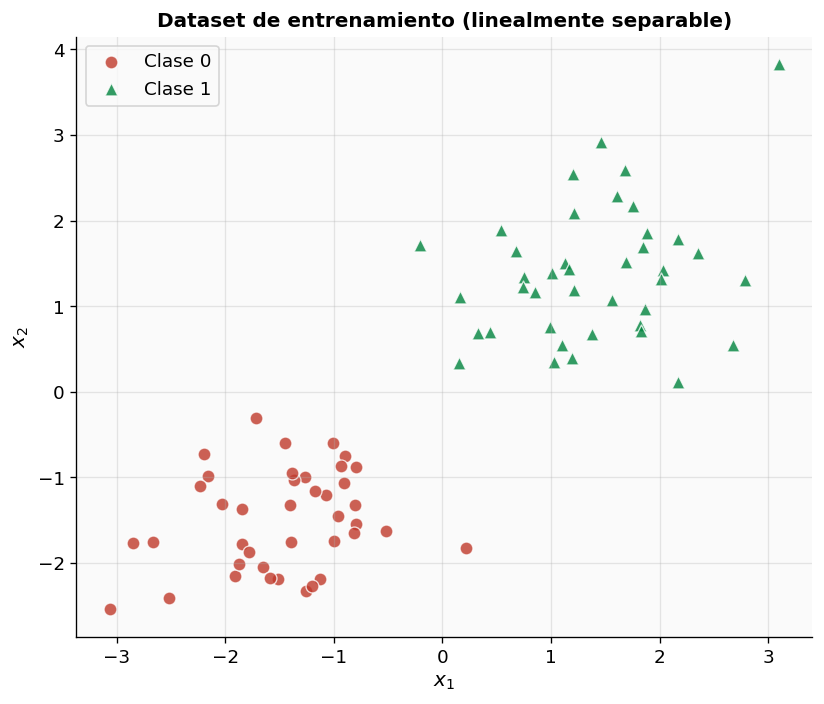

Dataset: 80 puntos, 40 de clase 0, 40 de clase 1


In [18]:
# [OK] Generar un dataset linealmente separable para visualizar el aprendizaje

def generar_datos(n=80, separacion=1.5, seed=42):
    """Genera dos nubes de puntos linealmente separables."""
    rng = np.random.default_rng(seed)
    n_por_clase = n // 2

    # Clase 0: centro en (-separacion, -separacion)
    X0 = rng.normal(loc=-separacion, scale=0.8, size=(n_por_clase, 2))
    # Clase 1: centro en (+separacion, +separacion)
    X1 = rng.normal(loc=+separacion, scale=0.8, size=(n_por_clase, 2))

    X = np.vstack([X0, X1])
    y = np.array([0]*n_por_clase + [1]*n_por_clase)
    return X, y


X_train, y_train = generar_datos(n=80, separacion=1.5)

# Visualizacion del dataset
fig, ax = plt.subplots(figsize=(7, 6))
for clase, color, marker, etiqueta in [(0, ROJO, "o", "Clase 0"), (1, VERDE, "^", "Clase 1")]:
    mask = y_train == clase
    ax.scatter(X_train[mask, 0], X_train[mask, 1], c=color, marker=marker,
               s=60, alpha=0.8, edgecolors="white", linewidths=0.8, label=etiqueta)
ax.set_xlabel("$x_1$", fontsize=12); ax.set_ylabel("$x_2$", fontsize=12)
ax.set_title("Dataset de entrenamiento (linealmente separable)", fontsize=12, fontweight="bold")
ax.legend(fontsize=11)
plt.tight_layout(); plt.show()

print(f"Dataset: {len(X_train)} puntos, {sum(y_train==0)} de clase 0, {sum(y_train==1)} de clase 1")


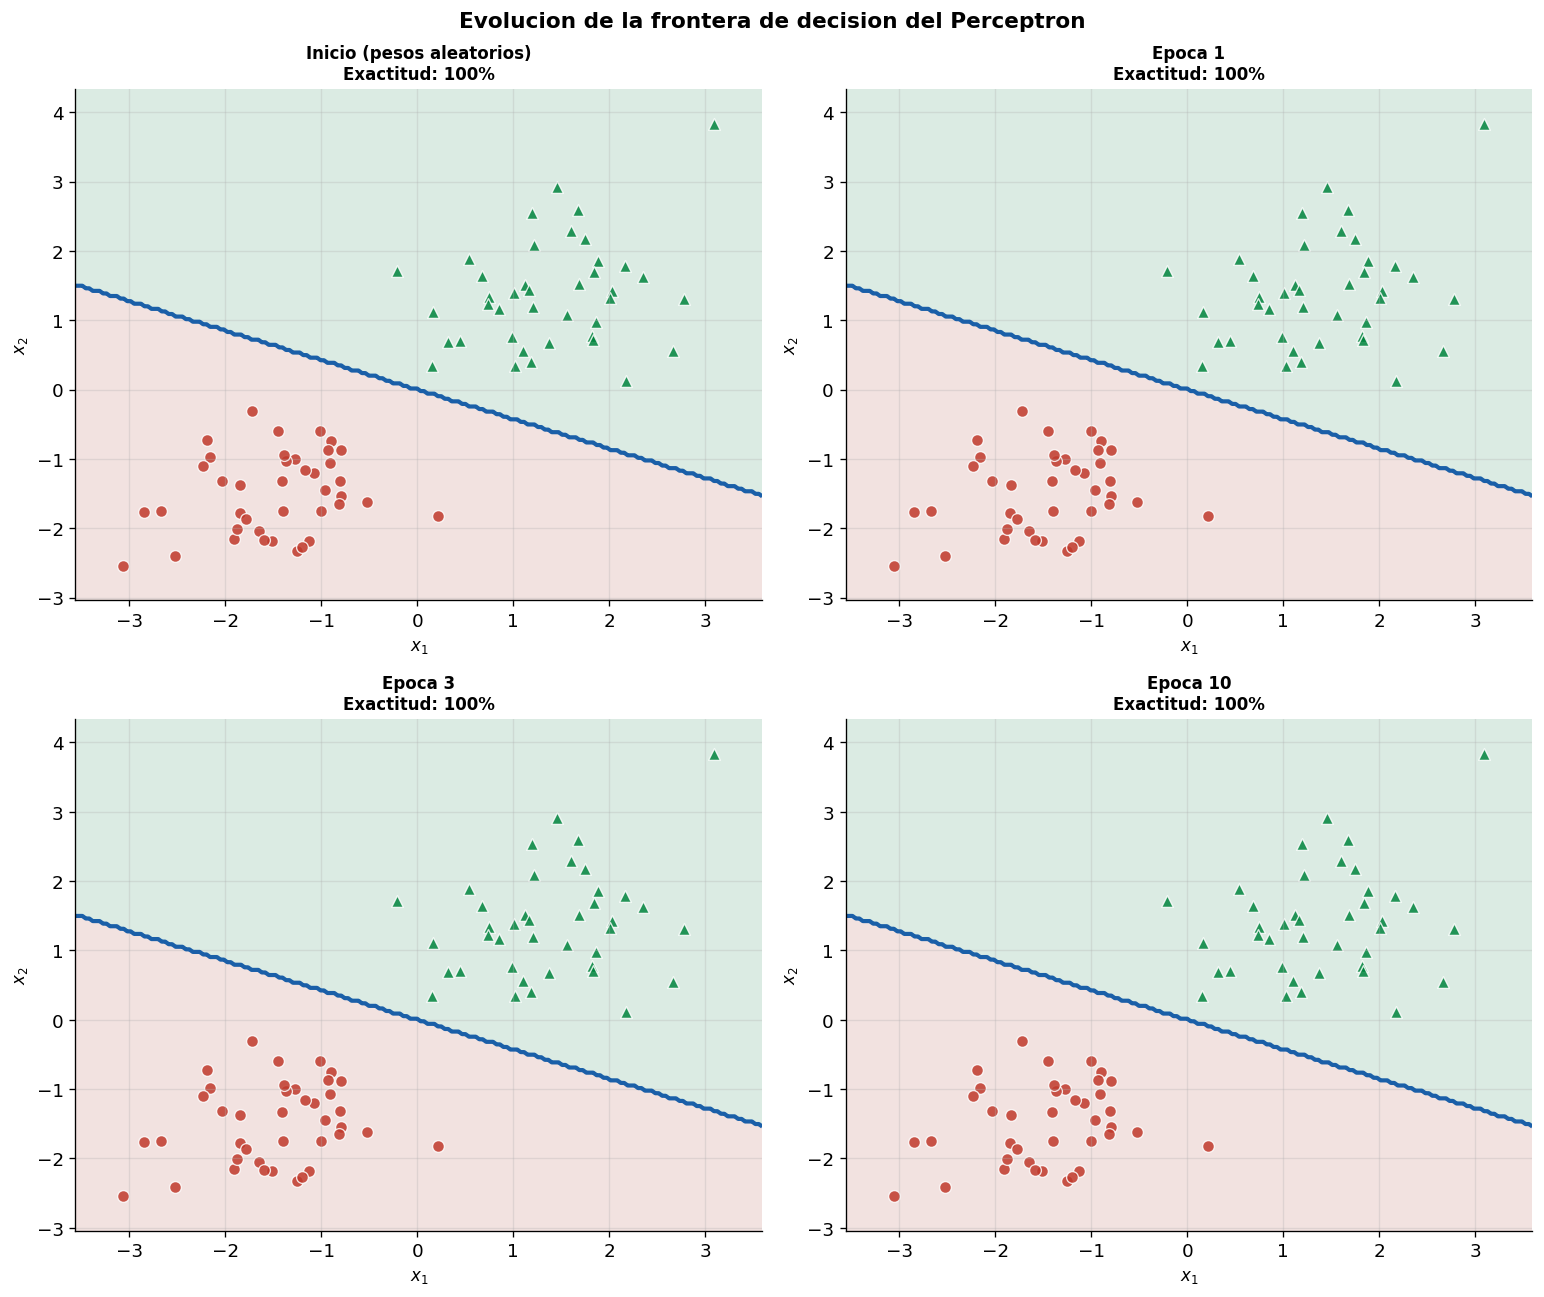

La linea azul es la frontera de decision: w @ x + b = 0
El area verde es donde el Perceptron predice clase 1.
El area roja es donde predice clase 0.


In [19]:
# [OK] Entrenar el Perceptron y visualizar la evolucion de la frontera

def dibujar_frontera(ax, perceptron, X, titulo="", mostrar_barra=True):
    """Dibuja los datos y la frontera de decision actual del Perceptron."""
    x1_min, x1_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    x2_min, x2_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 200),
                            np.linspace(x2_min, x2_max, 200))
    Z = np.array([perceptron.predecir([a, b])
                  for a, b in zip(xx1.ravel(), xx2.ravel())]).reshape(xx1.shape)

    ax.contourf(xx1, xx2, Z, alpha=0.12,
                colors=[ROJO, VERDE], levels=[-0.5, 0.5, 1.5])
    ax.contour(xx1, xx2, Z, levels=[0.5],
               colors=[AZUL], linewidths=2.5)

    for clase, color, marker in [(0, ROJO, "o"), (1, VERDE, "^")]:
        mask = y_train == clase
        ax.scatter(X[mask, 0], X[mask, 1], c=color, marker=marker,
                   s=50, alpha=0.85, edgecolors="white", linewidths=0.8)

    acc = np.mean([perceptron.predecir(xi) == yi
                   for xi, yi in zip(X, y_train)])
    ax.set_title(f"{titulo}\nExactitud: {acc:.0%}", fontsize=10, fontweight="bold")
    ax.set_xlabel("$x_1$", fontsize=10); ax.set_ylabel("$x_2$", fontsize=10)


# Guardar estado del Perceptron en distintas epocas
import copy

perceptron = Perceptron(n_entradas=2, eta=0.15)
epocas_captura = [0, 1, 3, 10]
estados = []

estados.append((0, copy.deepcopy(perceptron)))
historial_total = []

for epoca in range(1, max(epocas_captura) + 1):
    errores = 0
    for xi, yi in zip(X_train, y_train):
        if perceptron.entrenar_un_ejemplo(xi, yi) != 0:
            errores += 1
    historial_total.append(errores)
    if epoca in epocas_captura:
        estados.append((epoca, copy.deepcopy(perceptron)))


fig, axes = plt.subplots(2, 2, figsize=(13, 11))
for ax, (ep, p_estado) in zip(axes.flat, estados):
    titulo = f"Epoca {ep}" if ep > 0 else "Inicio (pesos aleatorios)"
    dibujar_frontera(ax, p_estado, X_train, titulo=titulo)

plt.suptitle("Evolucion de la frontera de decision del Perceptron",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

print("La linea azul es la frontera de decision: w @ x + b = 0")
print("El area verde es donde el Perceptron predice clase 1.")
print("El area roja es donde predice clase 0.")


Convergencia en epoca 2!


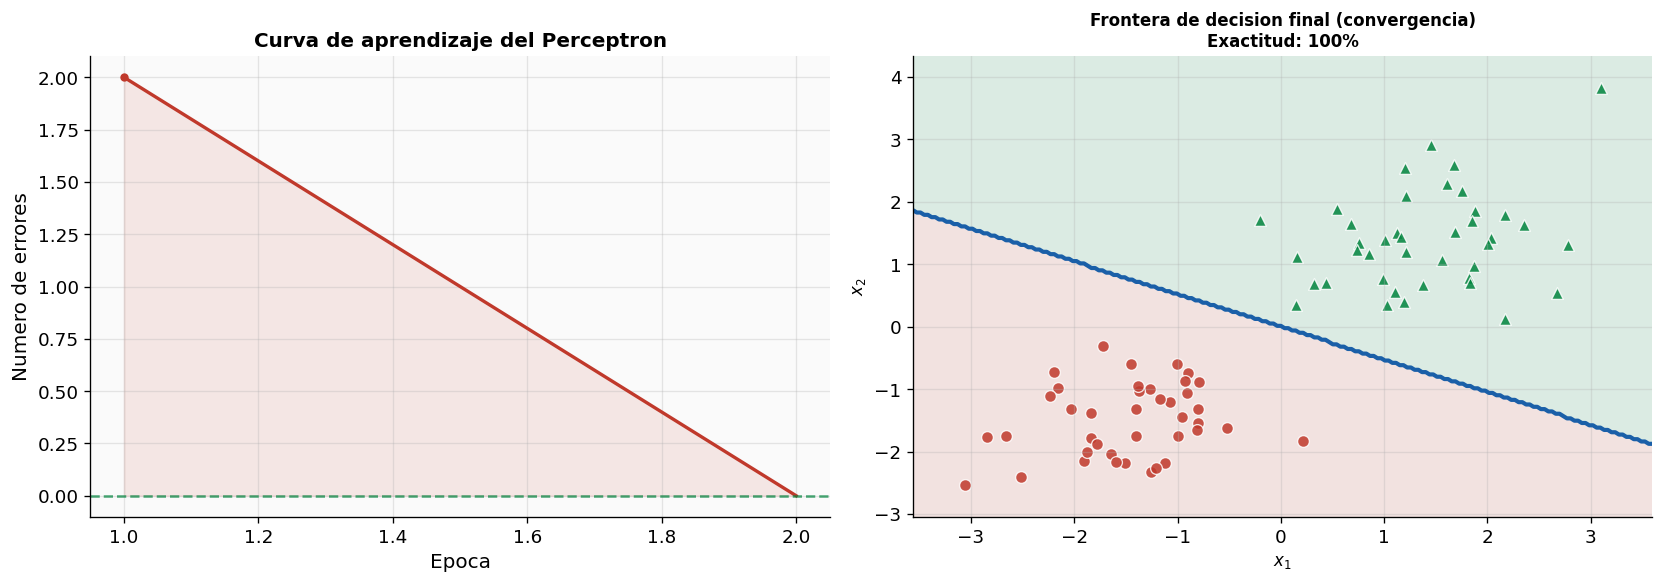

Exactitud final: 100.0%
Pesos aprendidos: w = [0.209 0.399],  b = 0.000


In [20]:
# [OK] Entrenar hasta convergencia y graficar la curva de aprendizaje

perceptron_final = Perceptron(n_entradas=2, eta=0.15)
historial = perceptron_final.entrenar(X_train, y_train, epocas=200)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva de error
axes[0].plot(range(1, len(historial)+1), historial,
             color=ROJO, linewidth=2, marker="o", markersize=4, markevery=3)
axes[0].axhline(0, color=VERDE, linewidth=1.5, linestyle="--", alpha=0.7)
axes[0].set_xlabel("Epoca", fontsize=12)
axes[0].set_ylabel("Numero de errores", fontsize=12)
axes[0].set_title("Curva de aprendizaje del Perceptron", fontsize=12, fontweight="bold")
axes[0].fill_between(range(1, len(historial)+1), historial,
                      alpha=0.1, color=ROJO)

# Frontera final
dibujar_frontera(axes[1], perceptron_final, X_train,
                  titulo="Frontera de decision final (convergencia)")

plt.tight_layout(); plt.show()

acc_final = np.mean([perceptron_final.predecir(xi) == yi
                      for xi, yi in zip(X_train, y_train)])
print(f"Exactitud final: {acc_final:.1%}")
print(f"Pesos aprendidos: w = {perceptron_final.w.round(3)},  b = {perceptron_final.b:.3f}")


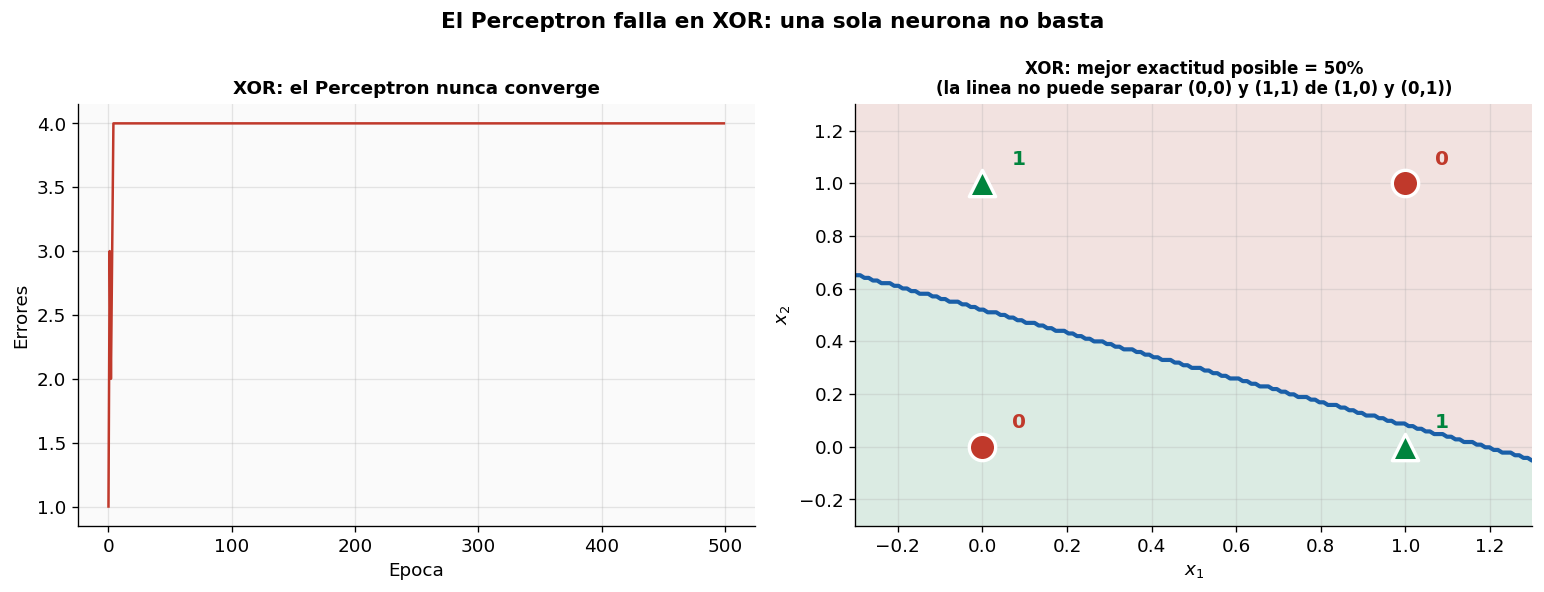

In [21]:
# [Ejercicio 3] Entrenar el Perceptron con XOR -- que ocurre?

X_xor = np.array([[0,0],[1,0],[0,1],[1,1]], dtype=float)
y_xor = np.array([0, 1, 1, 0])

perceptron_xor = Perceptron(n_entradas=2, eta=0.1)
hist_xor = perceptron_xor.entrenar(X_xor, y_xor, epocas=500)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(hist_xor, color=ROJO, linewidth=1.5)
axes[0].set_xlabel("Epoca", fontsize=11)
axes[0].set_ylabel("Errores", fontsize=11)
axes[0].set_title("XOR: el Perceptron nunca converge", fontsize=11, fontweight="bold")

# Visualizacion del intento
x1_range = np.linspace(-0.5, 1.5, 200)
x2_range = np.linspace(-0.5, 1.5, 200)
xx1, xx2 = np.meshgrid(x1_range, x2_range)
Z = np.array([perceptron_xor.predecir([a, b])
              for a, b in zip(xx1.ravel(), xx2.ravel())]).reshape(xx1.shape)

axes[1].contourf(xx1, xx2, Z, alpha=0.12, colors=[ROJO, VERDE], levels=[-0.5, 0.5, 1.5])
axes[1].contour(xx1, xx2, Z, levels=[0.5], colors=[AZUL], linewidths=2.5)

for xi, yi in zip(X_xor, y_xor):
    color  = VERDE if yi == 1 else ROJO
    marker = "^"   if yi == 1 else "o"
    axes[1].scatter(xi[0], xi[1], c=color, marker=marker, s=250, zorder=5,
                    edgecolors="white", linewidths=2)
    axes[1].text(xi[0]+0.07, xi[1]+0.07, str(yi), fontsize=12,
                 color=color, fontweight="bold")

acc_xor = np.mean([perceptron_xor.predecir(xi)==yi for xi, yi in zip(X_xor, y_xor)])
axes[1].set_title(f"XOR: mejor exactitud posible = {acc_xor:.0%}\n(la linea no puede separar (0,0) y (1,1) de (1,0) y (0,1))",
                  fontsize=10, fontweight="bold")
axes[1].set_xlabel("$x_1$", fontsize=11); axes[1].set_ylabel("$x_2$", fontsize=11)
axes[1].set_xlim(-0.3, 1.3); axes[1].set_ylim(-0.3, 1.3)

plt.suptitle("El Perceptron falla en XOR: una sola neurona no basta",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

# ================================================
# [Ejercicio 3] Responde en una celda de texto:
# 1. El numero de errores en la curva izquierda,
#    converge a cero? Por que o por que no?
# 2. Que tendria que cambiar en la arquitectura
#    para que XOR fuera posible?
# ================================================


**1.**  
No, el error no converge a cero porque XOR no se puede separar con una sola línea. El perceptrón solo aprende separaciones lineales, así que siempre se equivoca en algunos puntos.

**2.**  
Hay que usar una red neuronal con al menos una capa oculta. Eso permite hacer separaciones no lineales y sí resolver XOR.

## 6. El invierno de la IA: Minsky y Papert (1969)

En 1969, Marvin Minsky y Seymour Papert publicaron el libro **"Perceptrons"**,
donde demostraron matematicamente que:

1. Un Perceptron de una sola capa **no puede** aprender XOR ni ninguna funcion
   no linealmente separable
2. Escalar a problemas mas complejos seria computacionalmente prohibitivo

El efecto fue devastador: el financiamiento a la investigacion en redes neuronales
se corto casi por completo. Durante mas de una decada, el campo quedo practicamente
abandonado -- el primer **"invierno de la IA"**.

---

### Que faltaba?

Lo que Minsky no demostro -- porque aun no existia de forma practica -- era que
**apilar varias capas de neuronas** si puede resolver XOR y problemas mucho mas
complejos. El obstaculo era: *como entrenar una red con multiples capas?*

La respuesta llego en 1986 con David Rumelhart, Geoffrey Hinton y Ronald Williams:
el algoritmo de **retropropagacion del error** (*backpropagation*).

Eso es exactamente lo que veremos en el **Notebook 03**.


In [22]:
# [OK] Vista previa: XOR con una red de 2 capas (con numpy puro)
# Aqui DAMOS los pesos calculados a mano -- el entrenamiento lo veremos en NB03

def red_dos_capas(x, W1, b1, W2, b2):
    """Red con una capa oculta: resuelve XOR."""
    # Capa oculta
    z1   = W1 @ x + b1
    act1 = np.array([escalon(zi) for zi in z1])
    # Capa de salida
    z2   = W2 @ act1 + b2
    return escalon(z2)


# Pesos que resuelven XOR (calculados a mano)
# Capa oculta: 2 neuronas que aprenden AND y OR implicitamente
W1 = np.array([[1.0, 1.0], [1.0, 1.0]])
b1 = np.array([-1.5, -0.5])
# Capa de salida: combina las dos neuronas ocultas
W2 = np.array([-1.0, 1.0])
b2 = -0.5

print("Red de 2 capas resolviendo XOR:")
for xi, yi in zip(X_xor, y_xor):
    pred = red_dos_capas(xi, W1, b1, W2, b2)
    estado = "[OK]" if pred == yi else "[!]"
    print(f"  XOR{tuple(xi.astype(int))} = {pred}  (esperado {yi})  {estado}")

print()
print("Con dos capas, XOR es resoluble.")
print("El problema: como encontrar W1, b1, W2, b2 automaticamente a partir de datos?")
print("Respuesta: backpropagation -> Notebook 03.")


Red de 2 capas resolviendo XOR:
  XOR(np.int64(0), np.int64(0)) = 0  (esperado 0)  [OK]
  XOR(np.int64(1), np.int64(0)) = 1  (esperado 1)  [OK]
  XOR(np.int64(0), np.int64(1)) = 1  (esperado 1)  [OK]
  XOR(np.int64(1), np.int64(1)) = 0  (esperado 0)  [OK]

Con dos capas, XOR es resoluble.
El problema: como encontrar W1, b1, W2, b2 automaticamente a partir de datos?
Respuesta: backpropagation -> Notebook 03.


## 7. Resumen y puente hacia el Notebook 03

### Lo que aprendimos

| Concepto | Lo que aprendimos |
|----------|------------------|
| **McCulloch-Pitts (1943)** | La neurona como compuerta logica: suma ponderada + umbral |
| **Separabilidad lineal** | Una neurona solo puede separar clases con una linea (hiperplano) |
| **Perceptron (1957)** | La primera red que **aprende** sus pesos a partir de errores |
| **Regla de aprendizaje** | $w \leftarrow w + \eta (y - \hat{y}) x$ -- correccion proporcional al error |
| **Tasa de aprendizaje** $\eta$ | Controla el tamano de cada actualizacion |
| **XOR y las limitaciones** | Un Perceptron de una capa no puede resolver problemas no lineales |
| **Invierno de la IA** | Minsky (1969) paralizo el campo durante ~15 anos |

---

### La pregunta que queda abierta

Sabemos que necesitamos **varias capas**. Pero si hay multiples capas,
no hay una forma directa de saber cuanto contribuyo cada neurona al error total.

Esa es la pregunta que resolver a: *como asignar la culpa del error
a neuronas que estan lejos de la salida?*

La respuesta: **propagacion del gradiente hacia atras** (backpropagation).
Y para eso necesitamos una funcion de activacion **diferenciable**,
no el escalon discontinuo que usamos aqui.

---

### Siguiente: Notebook 03 -- Redes Neuronales con TensorFlow

Construiremos redes con multiples capas usando TensorFlow/Keras,
entenderemos que son las funciones de activacion, el gradiente, y el
algoritmo de backpropagation que hace posible el aprendizaje profundo.

---

*Analisis Numerico  |  Universidad Nacional de Colombia  |  Prof. Carlos Manuel Orrego Franco*
